In [39]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind

plt.style.use('ggplot')


In [40]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [41]:
df.shape

(7043, 21)

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [43]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [44]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [45]:
# Check Missing Values

df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [46]:
#Convert TotalCharges

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [47]:
# Check Duplicates

df.duplicated().sum()

np.int64(0)

## Exploratory Data Analysis

In [48]:
# Total Customers

len(df)

7043

In [49]:
# Churn Rate

churn_rate = (
    df["Churn"]
    .value_counts(normalize=True)
    *100
)

print(churn_rate)


Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [50]:
# Monthly Charges Statistics

df["MonthlyCharges"].describe()


,MonthlyCharges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


In [51]:
# Tenure Statistics

df["tenure"].describe()

,tenure
count,7043.000000
mean,32.371149
std,24.559481
min,0.000000
25%,9.000000
50%,29.000000
75%,55.000000
max,72.000000


## Visualization :

Churn Distribution

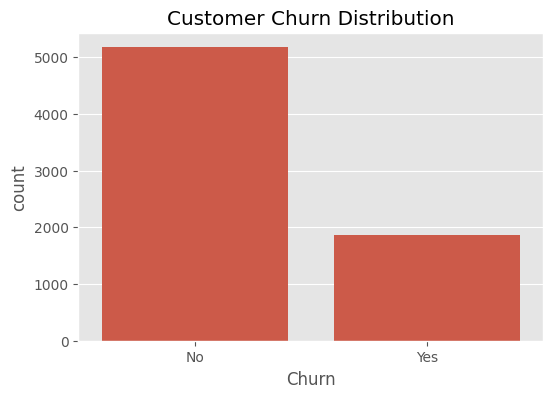

In [52]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Churn',
    data=df
)

plt.title("Customer Churn Distribution")

plt.show()

Contract Type vs Churn

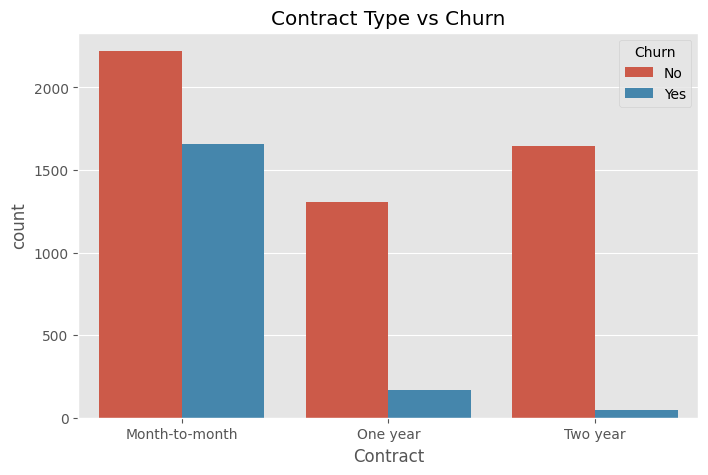

In [53]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Contract',
    hue='Churn',
    data=df
)

plt.title(
    "Contract Type vs Churn"
)

plt.show()

Monthly Charges vs Churn

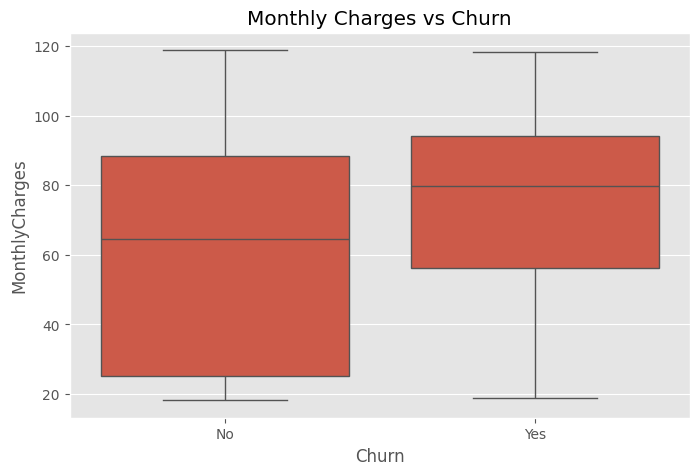

In [54]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)

plt.title(
    "Monthly Charges vs Churn"
)

plt.show()

Tenure Analysis

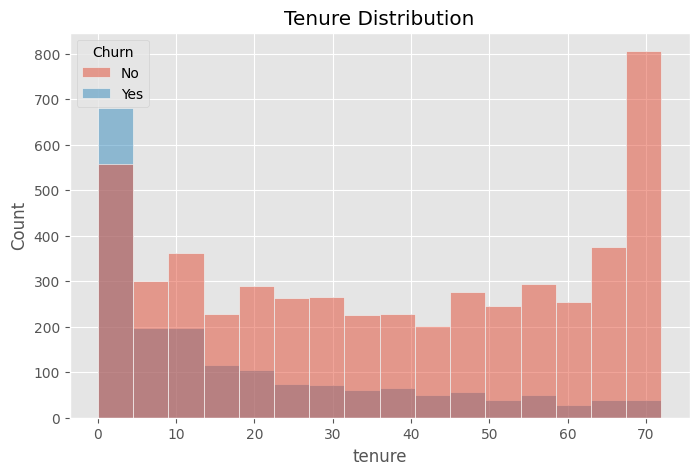

In [55]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='tenure',
    hue='Churn'
)

plt.title(
    "Tenure Distribution"
)

plt.show()

Payment Method Analysis

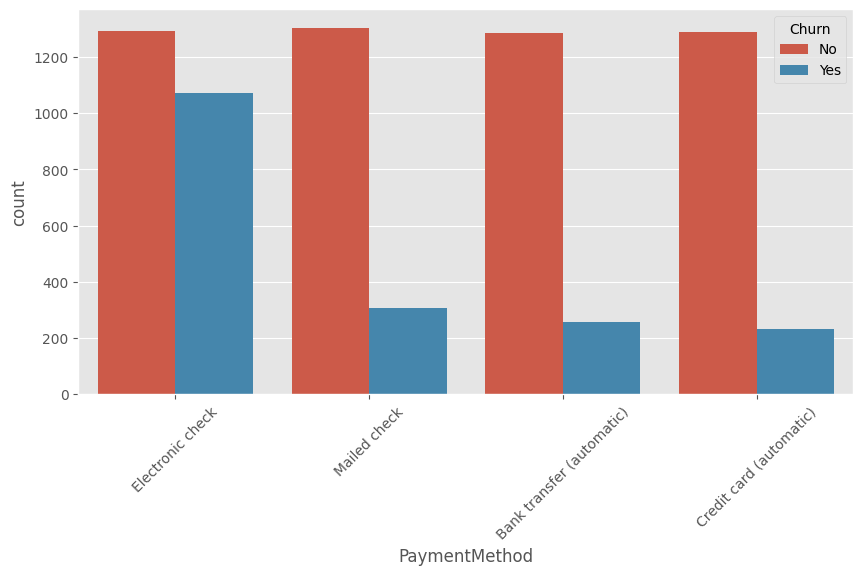

In [56]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='PaymentMethod',
    hue='Churn',
    data=df
)

plt.xticks(rotation=45)

plt.show()

Internet Service Analysis

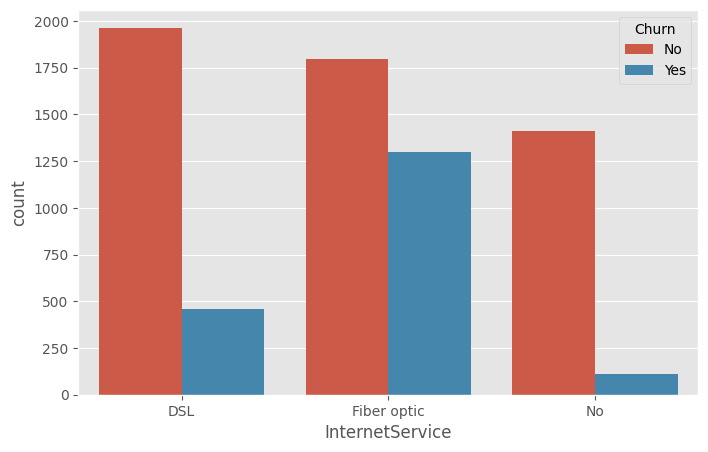

In [57]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='InternetService',
    hue='Churn',
    data=df
)

plt.show()

In [60]:
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})
corr = df[
    ['tenure',
     'MonthlyCharges',
     'SeniorCitizen',
     'Churn']
].corr()

Correlation Analysis

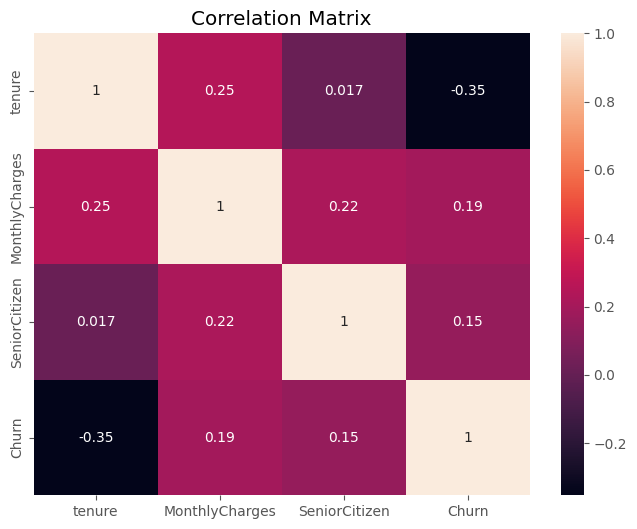

In [61]:


plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True
)

plt.title(
    "Correlation Matrix"
)

plt.show()

Customer Segmentation

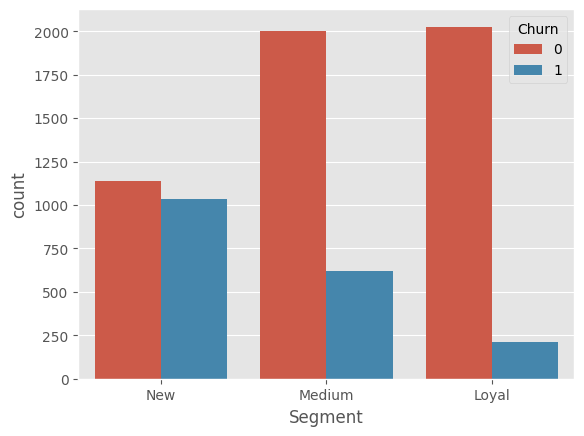

In [63]:
df['Segment'] = pd.cut(
    df['tenure'],
    bins=[0,12,48,72],
    labels=[
        'New',
        'Medium',
        'Loyal'
    ]
)

# Analysing
pd.crosstab(
    df['Segment'],
    df['Churn']
)

# Visualization :
sns.countplot(
    x='Segment',
    hue='Churn',
    data=df
)

plt.show()

## Hypothesis Testing

Does Monthly Charges affect churn?

H0

No impact.

H1

Impact exists.

In [64]:
churn_yes = df[
    df['Churn']=='Yes'
]['MonthlyCharges']

churn_no = df[
    df['Churn']=='No'
]['MonthlyCharges']


In [65]:
t_stat,p_value = ttest_ind(
    churn_yes,
    churn_no
)

print(p_value)


nan


/usr/local/lib/python3.12/dist-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


In [66]:
if p_value < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")


Fail to Reject H0


## Revenue Analysis
Revenue by churn:

In [67]:
df.groupby(
    'Churn'
)['MonthlyCharges'].sum()

,MonthlyCharges
Churn,
0,316985.75
1,139130.85


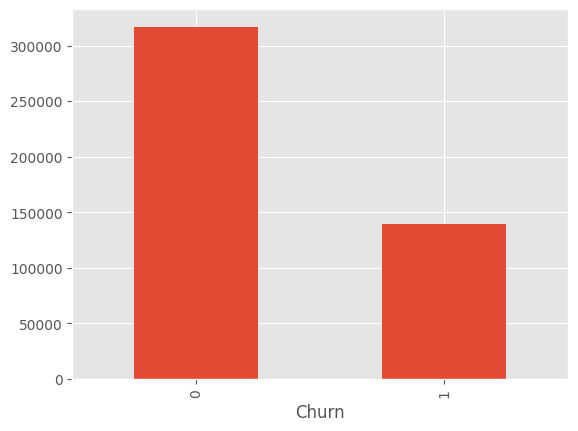

In [68]:
df.groupby(
    'Churn'
)['MonthlyCharges'].sum().plot(
    kind='bar'
)

plt.show()